<a href="https://colab.research.google.com/github/Kafkasyahrial/data-science-2026/blob/main/Pertemuan7_KafkaSyahrial_%5B240401010045%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Modul 7 - Data Science**

Nama: Kafka Syahrial

NIM: 240401010045

Kelas: IF405

**Impor Library & Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membuat dataset simulasi: Pengalaman Kerja (Tahun) vs Gaji (Juta Rupiah)
np.random.seed(42)
n = 200
experience = np.random.uniform(0, 15, n)
salary = 3.5 + 2.1 * experience + np.random.normal(0, 1.5, n)

# Scikit-learn membutuhkan fitur X dalam format array 2D
X = experience.reshape(-1, 1)
y = salary

print(f"Dataset berhasil dimuat. Total sampel: {len(X)}")

Dataset berhasil dimuat. Total sampel: 200


**Memisahkan Data (Train-Test Split)**

In [2]:
# Membagi dataset menjadi Train Set dan Test Set (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latihan (X_train): {X_train.shape[0]} sampel")
print(f"Jumlah data pengujian (X_test): {X_test.shape[0]} sampel")

Jumlah data latihan (X_train): 160 sampel
Jumlah data pengujian (X_test): 40 sampel


**Standardisasi Fitur (Feature Scaling)**

In [3]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit dan transform hanya pada training data
X_train_s = scaler.fit_transform(X_train)

# Transform saja pada testing data (mengikuti acuan dari data training)
X_test_s = scaler.transform(X_test)

print("Proses standardisasi fitur selesai tanpa memicu data leakage.")

Proses standardisasi fitur selesai tanpa memicu data leakage.


**Melatih Model Regresi Linear (Fit Model)**

In [4]:
# Inisialisasi dan pelatihan model menggunakan Ordinary Least Squares (OLS)
model = LinearRegression()
model.fit(X_train_s, y_train)

# Menampilkan parameter garis regresi yang terbentuk
print(f"Beta_0 (Intercept) : {model.intercept_:.3f}")
print(f"Beta_1 (Slope)     : {model.coef_[0]:.3f}")
print("\nInterpretasi:")
print(f"- Gaji rata-rata pada nilai X terstandardisasi 0 adalah sekitar {model.intercept_:.2f} juta rupiah.")
print(f"- Kenaikan satu unit standar deviasi dari pengalaman kerja meningkatkan prediksi gaji sebesar {model.coef_[0]:.2f} juta rupiah.")

Beta_0 (Intercept) : 18.776
Beta_1 (Slope)     : 9.308

Interpretasi:
- Gaji rata-rata pada nilai X terstandardisasi 0 adalah sekitar 18.78 juta rupiah.
- Kenaikan satu unit standar deviasi dari pengalaman kerja meningkatkan prediksi gaji sebesar 9.31 juta rupiah.


**Melakukan Prediksi & Evaluasi Performa**

In [5]:
# Melakukan prediksi pada data pengujian
y_pred = model.predict(X_test_s)

# Menghitung metrik evaluasi regresi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Menghitung RMSE secara manual
r2 = r2_score(y_test, y_pred)

print("=== Hasil Evaluasi Model ===")
print(f"MAE       = {mae:.3f} (Rata-rata kesalahan prediksi dalam juta)")
print(f"RMSE      = {rmse:.3f} (Akar dari rata-rata kesalahan kuadrat)")
print(f"R-Squared = {r2:.3f} (Kemampuan model menjelaskan variasi data)")

=== Hasil Evaluasi Model ===
MAE       = 1.258 (Rata-rata kesalahan prediksi dalam juta)
RMSE      = 1.562 (Akar dari rata-rata kesalahan kuadrat)
R-Squared = 0.970 (Kemampuan model menjelaskan variasi data)


**Membuat Grafik Evaluasi (Actual vs Predicted & Residual Plot)**

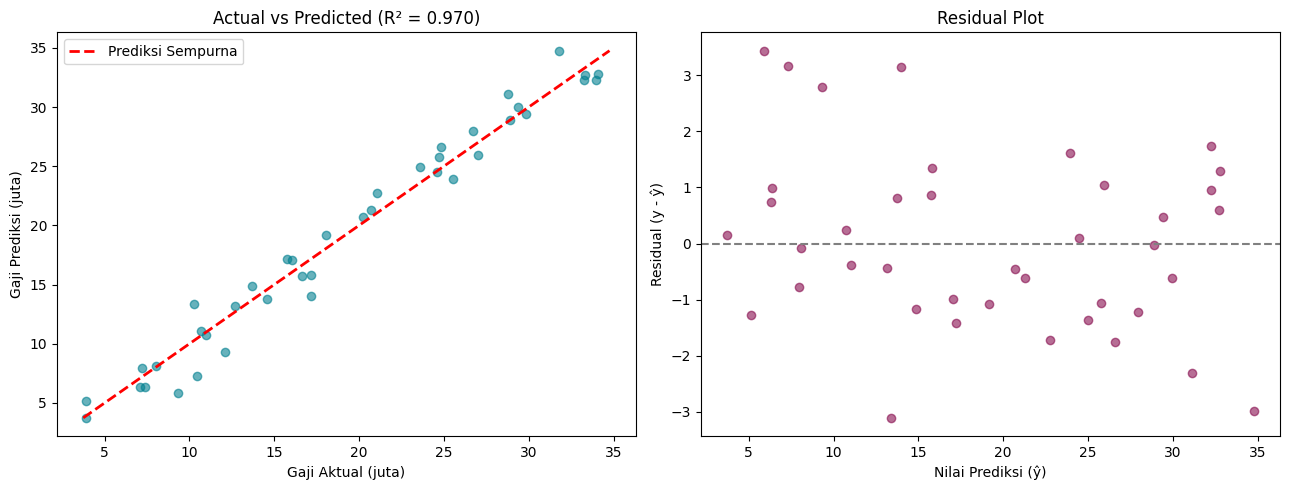


Cara Membaca Grafik:
1. Pada plot Actual vs Predicted, jika titik mendekati garis putus-putus merah, tandanya model makin akurat.
2. Pada Residual Plot, penyebaran titik secara ACAK di sekitar garis nol menandakan asumsi linearitas dan homoskedastisitas terpenuhi dengan baik.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#028090')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta)')
axes[0].set_ylabel('Gaji Prediksi (juta)')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#880E4F')
axes[1].axhline(0, color='gray', linestyle='--', lw=1.5)
axes[1].set_xlabel('Nilai Prediksi (ŷ)')
axes[1].set_ylabel('Residual (y - ŷ)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
# Menyimpan gambar grafik sesuai petunjuk instruksi
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCara Membaca Grafik:")
print("1. Pada plot Actual vs Predicted, jika titik mendekati garis putus-putus merah, tandanya model makin akurat.")
print("2. Pada Residual Plot, penyebaran titik secara ACAK di sekitar garis nol menandakan asumsi linearitas dan homoskedastisitas terpenuhi dengan baik.")